In [ ]:
pip install nltk pandas scikit-learn numpy

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [13]:
import random
import pandas as pd
import matplotlib.pyplot as plt


def simulate_conversation():
    msg_length = random.randint(3, 30)
    sentiment = random.uniform(-1, 1)
    intent_complexity = random.randint(1, 5)
    typo_rate = random.uniform(0, 0.3)
    response_delay = random.uniform(0, 5)

    politeness = random.uniform(0, 1)
    frustration = random.uniform(0, 1)
    grammar_score = random.uniform(0.5, 1)
    response_relevance = random.uniform(0, 1)
    context_retention = random.uniform(0, 1)
    fallback_rate = random.uniform(0, 0.4)
    turns = random.randint(1, 20)

    quality = (
        40
        + sentiment * 15
        - typo_rate * 25
        - response_delay * 2
        + intent_complexity * 2
        + politeness * 8
        - frustration * 10
        + grammar_score * 10
        + response_relevance * 20
        + context_retention * 15
        - fallback_rate * 20
        + turns * 0.5
    )

    noise = random.normalvariate(0, 3)
    quality += noise

    quality = max(0, min(100, quality))

    return [
        msg_length, sentiment, intent_complexity, typo_rate,
        response_delay, politeness, frustration, grammar_score,
        response_relevance, context_retention, fallback_rate,
        turns, quality
    ]


In [18]:
import pandas as pd

data = []
for _ in range(1000):
    data.append(simulate_conversation())

columns = [
    "msg_length", "sentiment", "intent_complexity", "typo_rate",
    "response_delay", "politeness", "frustration", "grammar_score",
    "response_relevance", "context_retention", "fallback_rate",
    "turns", "quality_score"
]


df = pd.DataFrame(data, columns=columns)
df.to_csv("conversation_simulation.csv", index=False)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

X = df.drop("quality_score", axis=1)
y = df["quality_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "MLP": MLPRegressor(max_iter=500),
    "Extra Trees": ExtraTreesRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
results_df.to_csv("model_results.csv", index=False)
print(results_df.sort_values("R2", ascending=False))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


               Model         MSE        R2
0             Linear    9.178613  0.950403
1              Ridge    9.514694  0.948587
8                MLP   15.708748  0.915118
5  Gradient Boosting   23.348629  0.873835
9        Extra Trees   42.467283  0.770528
4      Random Forest   46.984387  0.746119
2              Lasso   61.451586  0.667946
3      Decision Tree   97.412367  0.473631
7                SVR  160.832091  0.130942
6                KNN  170.189063  0.080381


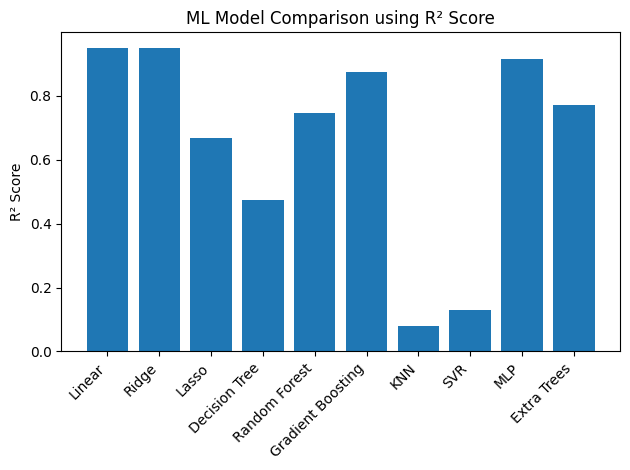

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² Score")
plt.title("ML Model Comparison using R² Score")
plt.tight_layout()
plt.savefig("model_r2_comparison.png")
plt.show()


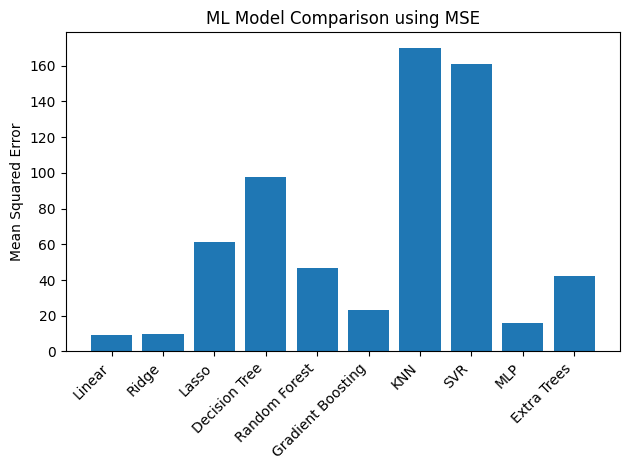

In [21]:
plt.figure()
plt.bar(results_df["Model"], results_df["MSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Squared Error")
plt.title("ML Model Comparison using MSE")
plt.tight_layout()
plt.savefig("model_mse_comparison.png")
plt.show()


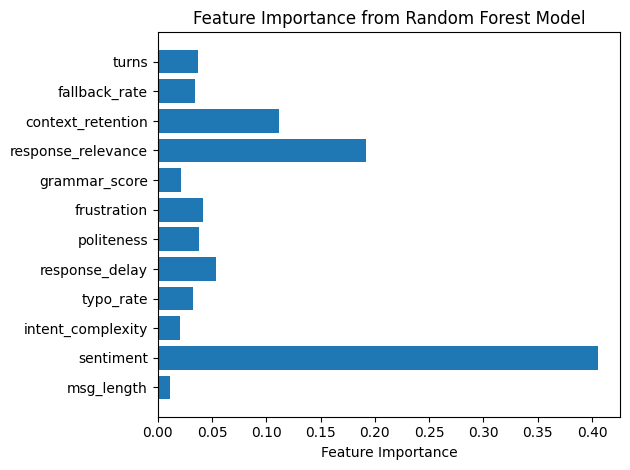

In [22]:
rf = RandomForestRegressor()
rf.fit(X, y)

plt.figure()
plt.barh(X.columns, rf.feature_importances_)
plt.xlabel("Feature Importance")
plt.title("Feature Importance from Random Forest Model")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
